# Introduction to Signal Processing
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Every measurement in movement neuroscience is a **signal** — a quantity that varies over time. EMG, force, joint angles, accelerometer data, EEG — they all arrive as raw time series contaminated with noise. Before you can extract meaningful results, you need to understand how to:

- **Decompose** a signal into its frequency components (what rhythms are present?)
- **Visualize** its frequency content (spectrum, PSD, spectrogram)
- **Filter** out noise while preserving the signal of interest

This notebook teaches these core signal processing operations step by step, starting from the math and building up to practical, reusable filter functions.

**Prerequisites:** Python Basics (L0), NumPy (L1), Matplotlib (L3).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---

## Table of Contents

**Part I — Frequency Analysis**
1. [Simulating a Composite Signal](#1)
2. [The Fast Fourier Transform (FFT)](#2)
3. [Frequency-Domain Filtering (Ideal Filter)](#3)
4. [Power Spectrum with `rfft`](#4)
5. [Power Spectral Density (PSD) with Welch's Method](#5)
6. [Spectrogram — Frequency Content Over Time](#6)

**Part II — Time-Domain Filtering**
7. [Why We Need Filters](#7)
8. [Butterworth Filter Design](#8)
9. [Reusable Filter Functions](#9)
10. [Filter Demo: Lowpass, Highpass, Bandpass, Bandstop](#10)
11. [Phase Distortion: `lfilter` vs `filtfilt`](#11)

**Part III — Practice**
12. [Exercises](#12)
13. [Summary & Further Reading](#13)

In [1]:
# ---- Setup: import all libraries ----

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.signal                       # Filtering, PSD, spectrograms
import scipy.fft                          # Modern FFT interface
from scipy import signal                  # Convenient alias

---
# Part I — Frequency Analysis

## 1. Simulating a Composite Signal <a id='1'></a>

Real biological signals are **mixtures** of many frequency components. For example, an EMG signal might contain:
- A low-frequency voluntary activation pattern (~1–5 Hz)
- Motor unit firing rates (~6–30 Hz)
- Power-line interference at 60 Hz (or 50 Hz in Europe)
- Random broadband noise from the amplifier

To understand signal processing tools, we'll first build a **synthetic signal** where we know exactly what's inside, so we can verify that our analysis recovers the correct answer.

### Key concepts

| Term | Symbol | Meaning |
|---|---|---|
| Sampling rate | $f_s$ | How many samples per second (Hz) |
| Nyquist frequency | $f_s / 2$ | Highest frequency we can represent |
| Frequency resolution | $\Delta f$ | Smallest frequency difference we can detect = $f_s / N$ |
| Number of samples | $N$ | Total data points = $f_s \times T$ |

In [2]:
# ---- Define a function that creates a known composite signal ----
# The signal has two sinusoidal components (at f1 and f2 Hz) plus Gaussian noise.
# Because WE design the signal, we know exactly what frequencies should appear.

np.random.seed(2345)                        # Reproducibility

def signal_samples(t, f1, f2):
    """Create a composite signal: 2*sin(f1) + 3*sin(f2) + noise."""
    return (2 * np.sin(f1 * 2 * np.pi * t) +   # Component 1: amplitude 2, frequency f1
            3 * np.sin(f2 * 2 * np.pi * t) +   # Component 2: amplitude 3, frequency f2
            2 * np.random.randn(*np.shape(t)))  # Gaussian noise (amplitude 2)

f1 = 1     # First frequency component: 1 Hz (slow oscillation)
f2 = 22    # Second frequency component: 22 Hz (faster oscillation)

In [3]:
# ---- Set up sampling parameters ----
# These parameters control HOW MUCH data we collect and at what resolution.

B = 30.0                          # Signal bandwidth (Hz) — highest frequency we care about
f_s = 2 * B                       # Sampling frequency (Hz) — must be ≥ 2× bandwidth (Nyquist theorem!)
delta_f = 0.01                    # Desired frequency resolution (Hz)
N = int(f_s / delta_f)            # Number of samples needed for this resolution
T = N / f_s                       # Total recording duration (seconds)

print(f"Sampling frequency: {f_s} Hz")
print(f"Number of samples:  {N}")
print(f"Recording duration: {T} seconds")
print(f"Nyquist frequency:  {f_s/2} Hz (highest detectable frequency)")

Sampling frequency: 60.0 Hz
Number of samples:  6000
Recording duration: 100.0 seconds
Nyquist frequency:  30.0 Hz (highest detectable frequency)


In [4]:
# ---- Generate the time vector and create the signal ----

t = np.linspace(0, T, N)                   # Time points from 0 to T seconds
f_t = signal_samples(t, f1, f2)            # Generate the composite signal

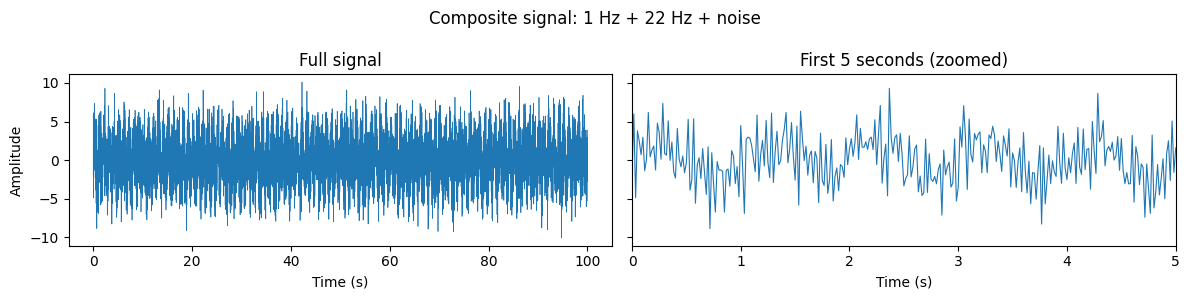

In [5]:
# ---- Plot the signal: full view and zoomed-in ----
# The left panel shows the entire recording.
# The right panel zooms into the first 5 seconds so you can see the waveform detail.

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

axes[0].plot(t, f_t, linewidth=0.5)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Full signal")

axes[1].plot(t, f_t, linewidth=0.8)
axes[1].set_xlim(0, 5)                     # Zoom to first 5 seconds
axes[1].set_xlabel("Time (s)")
axes[1].set_title("First 5 seconds (zoomed)")

fig.suptitle(f"Composite signal: {f1} Hz + {f2} Hz + noise", fontsize=12)
fig.tight_layout()
plt.show()

**What you should see:** A noisy waveform. The two sinusoidal components (1 Hz and 22 Hz) are buried in noise and not easy to see by eye. This is why we need frequency analysis — to reveal what's hidden in the signal.

---
## 2. The Fast Fourier Transform (FFT) <a id='2'></a>

The **Fourier Transform** decomposes a time-domain signal into its constituent **frequency components**. It answers the question: *"What sinusoidal frequencies, and at what amplitudes, are present in this signal?"*

The **Fast Fourier Transform (FFT)** is an efficient algorithm for computing this. It takes $N$ time-domain samples and produces $N$ frequency-domain values (complex numbers whose magnitude gives amplitude and whose angle gives phase).

### Key functions

| Function | What it does |
|---|---|
| `sp.fft.fft(signal)` | Compute the FFT → returns complex array of frequency components |
| `sp.fft.fftfreq(N, 1/fs)` | Generate the frequency values for each FFT bin |
| `abs(F)` | Magnitude (amplitude) of each frequency component |
| `np.angle(F)` | Phase of each frequency component |

In [6]:
# ---- Compute the FFT ----
# The FFT transforms the signal from the TIME domain to the FREQUENCY domain.

F = sp.fft.fft(f_t)                       # F is a complex array — each element is one frequency bin
f = sp.fft.fftfreq(N, 1/f_s)             # Frequency value (Hz) for each bin

print(f"Signal length: {len(f_t)} samples")
print(f"FFT length:    {len(F)} bins (same as signal length)")
print(f"Frequency range: {f.min():.2f} to {f.max():.2f} Hz")

Signal length: 6000 samples
FFT length:    6000 bins (same as signal length)
Frequency range: -30.00 to 29.99 Hz


In [7]:
# ---- Important: the FFT output contains BOTH positive and negative frequencies ----
# For real-valued signals, the negative frequencies are just a mirror of the positive ones.
# We only need the positive half (0 to Nyquist frequency).

mask = np.where(f >= 0)                    # Select only non-negative frequencies

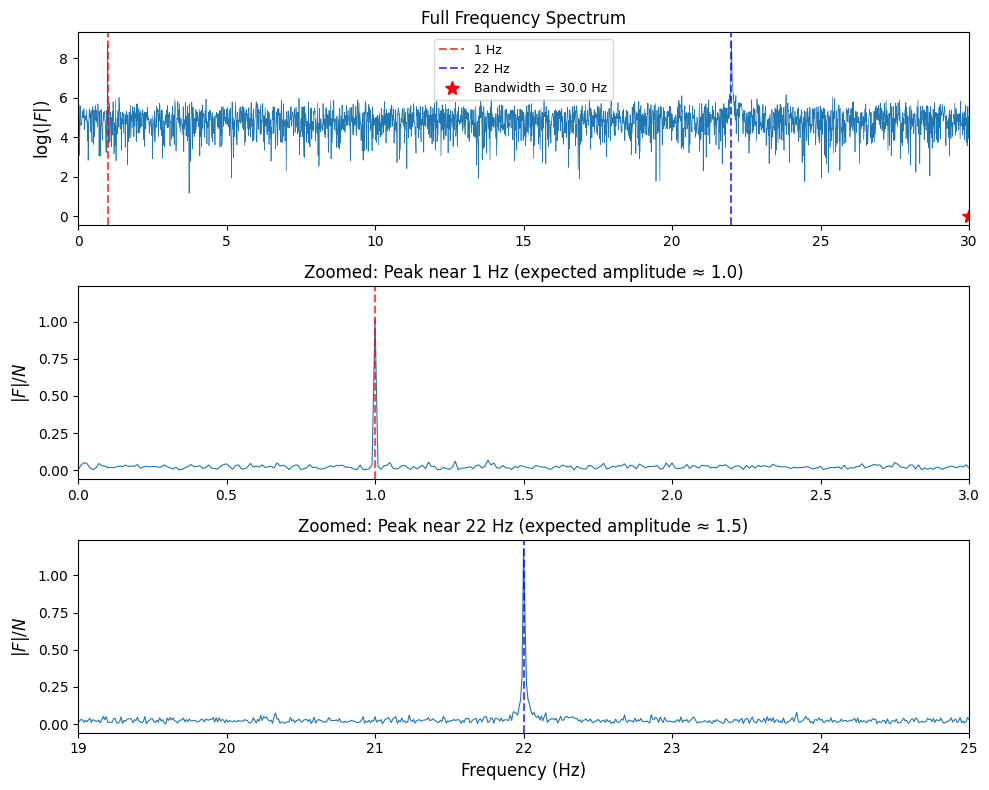

In [8]:
# ---- Plot the frequency spectrum ----
# Top: log magnitude (full frequency range) — shows the overall spectral shape.
# Middle: zoomed near 1 Hz — should show the f1 peak.
# Bottom: zoomed near 22 Hz — should show the f2 peak.

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Panel 1: Full spectrum (log scale)
axes[0].plot(f[mask], np.log(abs(F[mask])), linewidth=0.5)
axes[0].axvline(f1, color='red', linestyle='--', alpha=0.7, label=f'{f1} Hz')
axes[0].axvline(f2, color='blue', linestyle='--', alpha=0.7, label=f'{f2} Hz')
axes[0].plot(B, 0, 'r*', markersize=10, label=f'Bandwidth = {B} Hz')
axes[0].set_xlim(0, B)
axes[0].set_ylabel("$\\log(|F|)$", fontsize=12)
axes[0].set_title("Full Frequency Spectrum")
axes[0].legend(fontsize=9)

# Panel 2: Zoom around f1 = 1 Hz
axes[1].plot(f[mask], abs(F[mask]) / N, linewidth=0.8)   # Normalized amplitude
axes[1].axvline(f1, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlim(0, 3)
axes[1].set_ylabel("$|F|/N$", fontsize=12)
axes[1].set_title(f"Zoomed: Peak near {f1} Hz (expected amplitude ≈ 1.0)")

# Panel 3: Zoom around f2 = 22 Hz
axes[2].plot(f[mask], abs(F[mask]) / N, linewidth=0.8)
axes[2].axvline(f2, color='blue', linestyle='--', alpha=0.7)
axes[2].set_xlim(19, 25)
axes[2].set_xlabel("Frequency (Hz)", fontsize=12)
axes[2].set_ylabel("$|F|/N$", fontsize=12)
axes[2].set_title(f"Zoomed: Peak near {f2} Hz (expected amplitude ≈ 1.5)")

fig.tight_layout()
plt.show()

**What you should see:** Sharp peaks at exactly 1 Hz and 22 Hz, sitting above a broad noise floor. The FFT has successfully **revealed the hidden frequency components** that were invisible in the time-domain plot.

---
## 3. Frequency-Domain Filtering (Ideal Filter) <a id='3'></a>

The simplest way to filter is in the frequency domain: set unwanted frequency components to zero, then convert back to the time domain with the **inverse FFT**.

This is called an **ideal filter** — it has a perfectly sharp cutoff. In practice, ideal filters cause artifacts (ringing), so we'll use Butterworth filters later. But this demonstrates the core concept.

In [9]:
# ---- Frequency-domain low-pass filter ----
# Strategy: zero out all frequency components above 2 Hz, then inverse-FFT.
# This should recover just the 1 Hz component.

cutoff = 2                                 # Keep only frequencies below 2 Hz
F_filtered = F * (abs(f) < cutoff)         # Multiply: 1 if |f| < 2, else 0
f_t_filtered = sp.fft.ifft(F_filtered)    # Inverse FFT → back to time domain

print(f"Kept frequencies below {cutoff} Hz")
print(f"Filtered signal is complex (tiny imaginary part): {f_t_filtered.dtype}")
print(f"Max imaginary component: {np.max(np.abs(f_t_filtered.imag)):.2e} (essentially zero)")

Kept frequencies below 2 Hz
Filtered signal is complex (tiny imaginary part): complex128
Max imaginary component: 8.08e-16 (essentially zero)


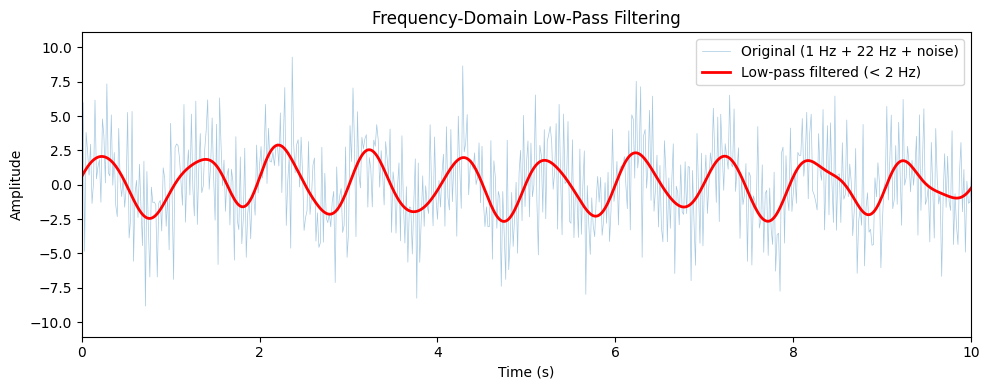

In [10]:
# ---- Plot original vs filtered signal ----

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, f_t, alpha=0.4, linewidth=0.5, label='Original (1 Hz + 22 Hz + noise)')
ax.plot(t, f_t_filtered.real, color='red', linewidth=2, label=f'Low-pass filtered (< {cutoff} Hz)')
ax.set_xlim(0, 10)                        # Show first 10 seconds
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Frequency-Domain Low-Pass Filtering")
ax.legend()
plt.tight_layout()
plt.show()

**What you should see:** The filtered signal (red) is a clean 1 Hz sinusoid — the 22 Hz component and all the noise have been removed. The filter extracted exactly the slow oscillation.

---
## 4. Power Spectrum with `rfft` <a id='4'></a>

For real-valued signals (which all physical measurements are), `scipy.fft.rfft` is faster than `fft` because it only computes the positive-frequency half of the spectrum.

| Function | Input | Output |
|---|---|---|
| `sp.fft.fft()` | $N$ samples | $N$ complex values (+ and − frequencies) |
| `scipy.fft.rfft()` | $N$ samples | $N/2 + 1$ complex values (positive only) |

In [11]:
# ---- Create a new signal with 3 known frequency components ----

fs = 1000                                  # Sampling rate: 1000 Hz
t = np.linspace(0, 1, fs)                  # 1 second of data
y = (np.sin(2*np.pi*6*t) +                 # 6 Hz component
     np.sin(2*np.pi*10*t) +                # 10 Hz component
     np.sin(2*np.pi*13*t))                 # 13 Hz component

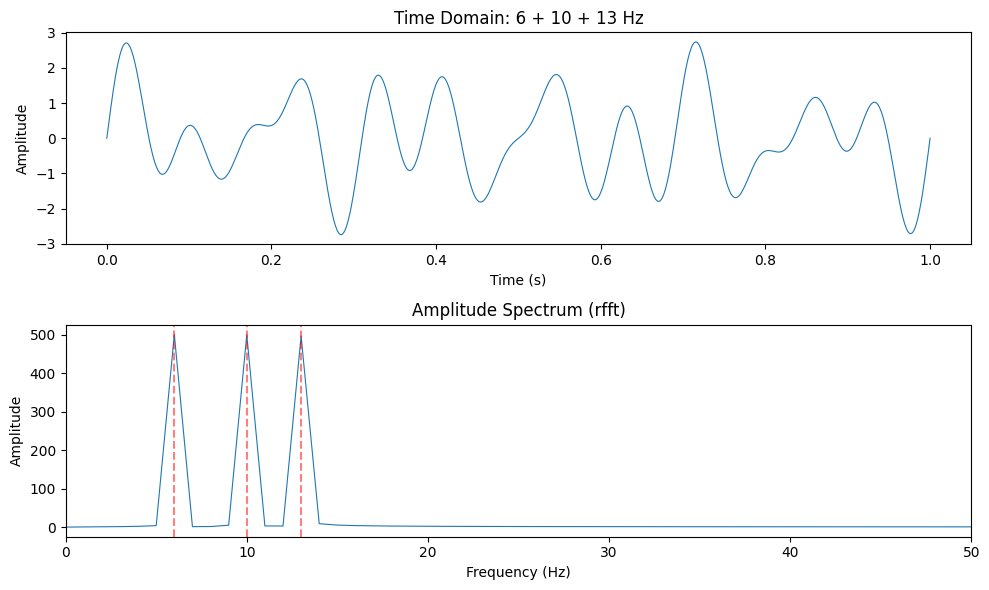

In [12]:
# ---- Compute and plot the amplitude spectrum ----

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Top: time domain
ax[0].plot(t, y, linewidth=0.8)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Time Domain: 6 + 10 + 13 Hz')

# Bottom: frequency domain using rfft
out = sp.fft.rfft(y)                       # FFT for real-valued signals (positive freqs only)
mag = np.abs(out)                          # Magnitude = amplitude of each frequency
freqs = sp.fft.rfftfreq(len(y), d=1/fs)   # Frequency axis (Hz)

ax[1].plot(freqs, mag, linewidth=0.8)
ax[1].set_xlim([0, 50])                    # Zoom to 0–50 Hz
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Amplitude')
ax[1].set_title('Amplitude Spectrum (rfft)')

# Mark the expected peaks
for freq in [6, 10, 13]:
    ax[1].axvline(freq, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. Power Spectral Density (PSD) with Welch's Method <a id='5'></a>

The raw FFT can be noisy. **Welch's method** provides a smoother estimate of the **power spectral density (PSD)** by:
1. Splitting the signal into overlapping segments
2. Computing the FFT of each segment
3. Averaging the power spectra across segments

The result is much smoother and is the standard way to report frequency content in neuroscience papers.

```python
freqs, psd = scipy.signal.welch(signal, fs=sampling_rate, nperseg=segment_length)
```

In [13]:
# ---- Create a signal with known components PLUS noise ----
# The PSD should still reveal the peaks even through the noise.

t = np.linspace(0, 1, 1000)               # 1 second at 1000 Hz
y_clean = (np.sin(2*np.pi*12*t) +         # 12 Hz: amplitude 1
           2*np.sin(2*np.pi*24*t) +        # 24 Hz: amplitude 2
           3*np.sin(2*np.pi*36*t))         # 36 Hz: amplitude 3
y_noisy = y_clean + np.random.randn(len(y_clean)) * 2  # Add heavy noise

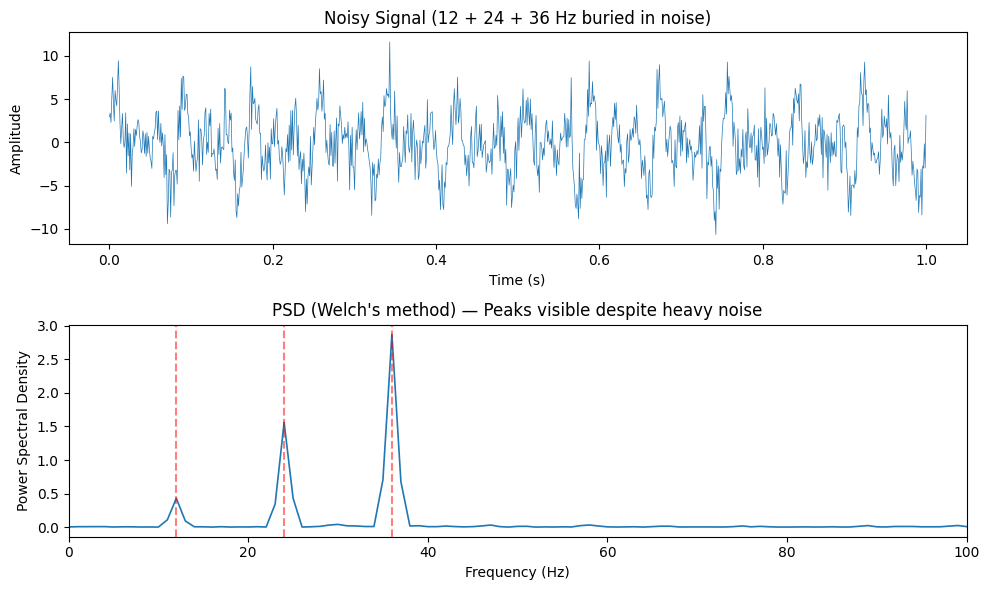

In [14]:
# ---- Compute PSD using Welch's method ----
# nperseg controls the tradeoff: longer segments → better frequency resolution but noisier.

freqs, psd = sp.signal.welch(y_noisy, fs=1000, nperseg=1000)

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Top: time domain (noisy — hard to see the components)
ax[0].plot(t, y_noisy, linewidth=0.5)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Noisy Signal (12 + 24 + 36 Hz buried in noise)')

# Bottom: PSD reveals the peaks clearly
ax[1].plot(freqs, psd, linewidth=1.2)
ax[1].set_xlim([0, 100])
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Power Spectral Density')
ax[1].set_title('PSD (Welch\'s method) — Peaks visible despite heavy noise')

# Mark expected peaks
for freq in [12, 24, 36]:
    ax[1].axvline(freq, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Key takeaway:** Even though the time-domain signal looks like pure noise, the PSD cleanly reveals all three frequency peaks. This is the power of spectral analysis.

---
## 6. Spectrogram — Frequency Content Over Time <a id='6'></a>

A **spectrogram** shows how the frequency content of a signal **changes over time**. It's a 2-D heatmap where the x-axis is time, the y-axis is frequency, and the color represents power.

**Neuroscience use:** EMG spectrograms during different movement phases, EEG spectrograms showing alpha/beta band changes during motor planning.

We'll create a signal with a constant 100 Hz tone and a transient 400 Hz "chirp" that appears only briefly.

In [15]:
# ---- Create a signal with a transient high-frequency burst ----

dt = 0.0005                                # Sampling interval (= 2000 Hz sampling rate)
t_spec = np.arange(0, 20, dt)              # 20 seconds of data

s1 = np.sin(2 * np.pi * 100 * t_spec)     # Constant 100 Hz tone (always present)
s2 = 2 * np.sin(2 * np.pi * 400 * t_spec) # 400 Hz burst (will appear only briefly)
s2[t_spec <= 10] = 0                       # Zero out before 10 seconds
s2[t_spec >= 12] = 0                       # Zero out after 12 seconds — burst only at 10-12s
noise = 0.01 * np.random.randn(len(t_spec))  # Small amount of noise

x = s1 + s2 + noise                       # Composite signal

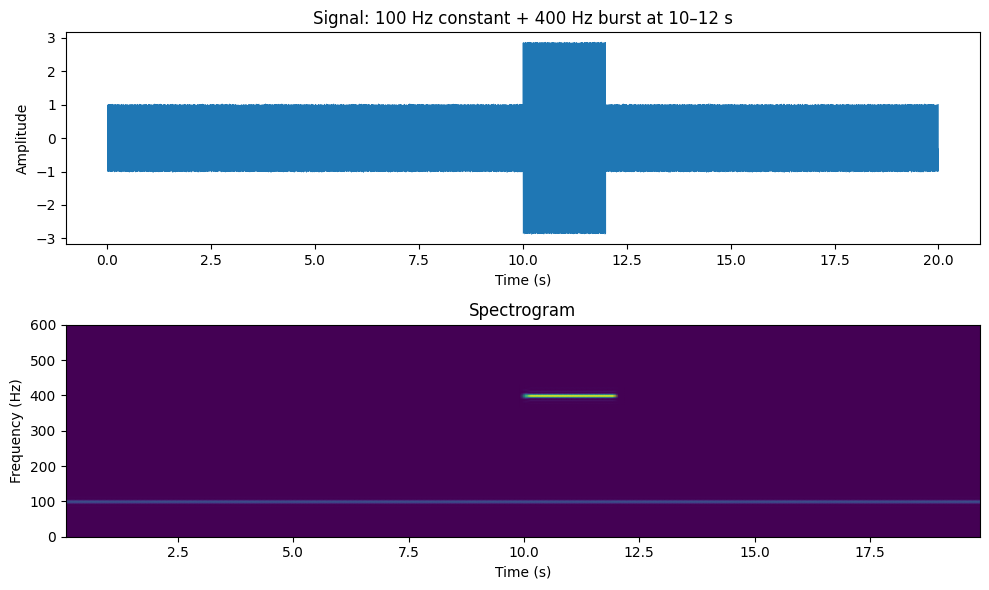

In [16]:
# ---- Compute and plot the spectrogram ----

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Top: time domain
ax[0].plot(t_spec, x, linewidth=0.3)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Signal: 100 Hz constant + 400 Hz burst at 10–12 s')

# Bottom: spectrogram
f_sg, t_sg, Sxx = sp.signal.spectrogram(x, fs=1/dt, nfft=1024)
ax[1].pcolormesh(t_sg, f_sg, Sxx, shading='gouraud')  # Color = power
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_title('Spectrogram')
ax[1].set_ylim(0, 600)                    # Show up to 600 Hz

plt.tight_layout()
plt.show()

**What you should see:** A constant horizontal band at 100 Hz (always present), and a brief bright spot at 400 Hz between 10–12 seconds (the transient burst). The spectrogram reveals *when* each frequency was active.

---
# Part II — Time-Domain Filtering

## 7. Why We Need Filters <a id='7'></a>

Biological signals are **always noisy**. Before analysis, we need to separate the signal of interest from the noise. Filters do this by selectively passing or rejecting specific frequency ranges.

| Filter type | What it does | Example use |
|---|---|---|
| **Low-pass** | Keeps frequencies **below** a cutoff | Smooth kinematic data (remove sensor noise) |
| **High-pass** | Keeps frequencies **above** a cutoff | Remove baseline drift from EMG |
| **Band-pass** | Keeps frequencies **between** two cutoffs | Isolate the EMG frequency band (20–450 Hz) |
| **Band-stop** (notch) | Removes frequencies **between** two cutoffs | Remove 60 Hz power-line noise |

Let's first look at a noisy signal and its PSD to motivate why filtering is necessary.

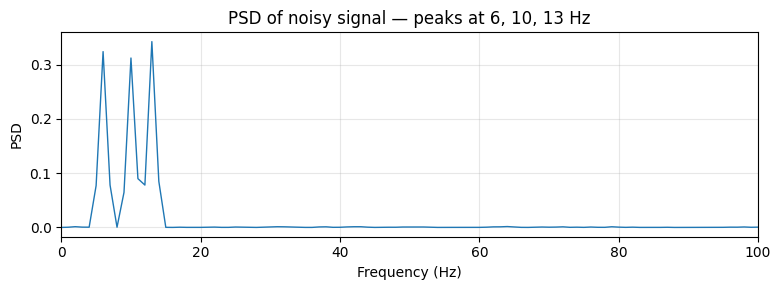

In [17]:
# ---- Create a noisy signal with known frequency peaks ----

fs = 1000                                  # Sampling rate (Hz)
f1, f2, f3 = 6, 10, 13                    # Three signal components (Hz)
t = np.linspace(0, 1, fs)                  # 1 second of data

y_clean = (np.sin(2*np.pi*f1*t) +         # 6 Hz
           np.sin(2*np.pi*f2*t) +          # 10 Hz
           np.sin(2*np.pi*f3*t))           # 13 Hz
y_noisy = y_clean + np.random.randn(len(t)) * 0.5  # Add noise

# Show the PSD — peaks should be visible above the noise floor
freqs, psd = sp.signal.welch(y_noisy, fs=fs, nperseg=fs)

plt.figure(figsize=(8, 3))
plt.plot(freqs, psd, linewidth=1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.xlim([0, 100])
plt.title('PSD of noisy signal — peaks at 6, 10, 13 Hz')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Butterworth Filter Design <a id='8'></a>

The **Butterworth filter** is the most commonly used filter in biomechanics and motor control research. It has a **maximally flat passband** (no ripples) and a smooth rolloff.

Key parameters:
- **Order**: How steep the rolloff is (higher = sharper cutoff, but more phase distortion)
- **Cutoff frequency**: Where the filter transitions from pass to stop
- **Type**: 'low', 'high', 'bandpass', or 'bandstop'

The **cutoff frequency** is defined as the **-3 dB point** — the frequency where the output power drops to half of the input power.

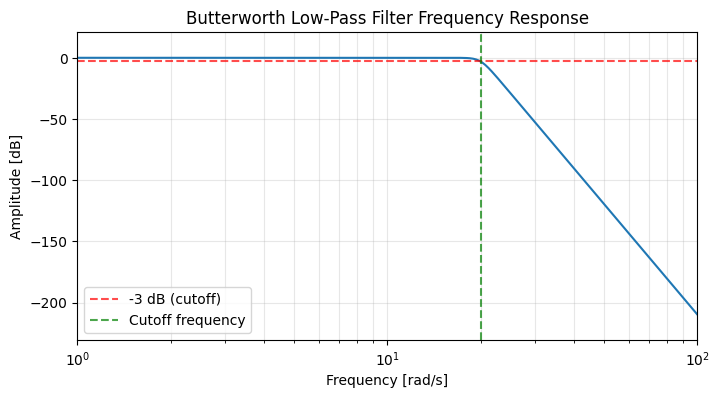

In [18]:
# ---- Visualize the frequency response of a Butterworth filter ----
# This shows WHAT the filter does to each frequency.

b, a = signal.butter(15, 20, 'low', analog=True)  # 15th-order, 20 rad/s cutoff
w, h = signal.freqs(b, a)                          # Compute frequency response

plt.figure(figsize=(8, 4))
plt.semilogx(w, 20 * np.log10(abs(h)))             # Plot in decibels (dB)
plt.title('Butterworth Low-Pass Filter Frequency Response')
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Amplitude [dB]')
plt.axhline(-3, color='red', linestyle='--', alpha=0.7, label='-3 dB (cutoff)')  # -3 dB line
plt.axvline(20, color='green', linestyle='--', alpha=0.7, label='Cutoff frequency')  # Cutoff
plt.margins(0, 0.1)
plt.grid(which='both', axis='both', alpha=0.3)
plt.legend()
plt.show()

**Reading the plot:** Frequencies below the cutoff pass through at 0 dB (unchanged). Frequencies above the cutoff are increasingly attenuated. The -3 dB line marks where the filter transitions from "passing" to "blocking."

### Key filter terminology

| Term | Meaning |
|---|---|
| **Passband** | Frequency range where signals pass through unchanged |
| **Stopband** | Frequency range where signals are attenuated (blocked) |
| **Cutoff frequency** | The -3 dB transition point between pass and stop |
| **Rolloff** | How quickly the filter transitions (steeper = higher order) |
| **Filter order** | Controls rolloff steepness (2nd order = 12 dB/octave, 4th = 24 dB/octave) |

---
## 9. Reusable Filter Functions <a id='9'></a>

Here are four ready-to-use filter functions that you can copy into any analysis script. They all use:
- `scipy.signal.butter()` to design the filter coefficients
- `scipy.signal.filtfilt()` to apply the filter **forward and backward** (zero-phase — more on this in Section 11)

**Important:** The cutoff frequency must be **normalized** to the Nyquist frequency: `Wn = cutoff / (fs / 2)`.

In [19]:
# ---- Four reusable Butterworth filter functions ----
# Copy these into your own analysis scripts!

def plg_lowpass(y, samprate, cutoff, order=2):
    """Low-pass filter: keeps frequencies BELOW cutoff."""
    w = cutoff / (samprate / 2)            # Normalize to Nyquist frequency
    b, a = sp.signal.butter(N=order, Wn=w, btype='lowpass')  # Design filter
    yf = sp.signal.filtfilt(b, a, y)       # Apply zero-phase (forward + backward)
    return yf

def plg_highpass(y, samprate, cutoff, order=2):
    """High-pass filter: keeps frequencies ABOVE cutoff."""
    w = cutoff / (samprate / 2)
    b, a = sp.signal.butter(N=order, Wn=w, btype='highpass')
    yf = sp.signal.filtfilt(b, a, y)
    return yf

def plg_bandpass(y, samprate, cutoffs, order=2):
    """Band-pass filter: keeps frequencies BETWEEN cutoffs[0] and cutoffs[1]."""
    w = [c / (samprate / 2) for c in cutoffs]  # Normalize both cutoffs
    b, a = sp.signal.butter(N=order, Wn=w, btype='bandpass')
    yf = sp.signal.filtfilt(b, a, y)
    return yf

def plg_bandstop(y, samprate, cutoffs, order=2):
    """Band-stop (notch) filter: REMOVES frequencies between cutoffs[0] and cutoffs[1]."""
    w = [c / (samprate / 2) for c in cutoffs]
    b, a = sp.signal.butter(N=order, Wn=w, btype='bandstop')
    yf = sp.signal.filtfilt(b, a, y)
    return yf

print("All four filter functions defined.")

All four filter functions defined.


---
## 10. Filter Demo: Lowpass, Highpass, Bandpass, Bandstop <a id='10'></a>

Let's test all four filters on **white noise** — a signal that has equal power at all frequencies. This makes it easy to see exactly which frequencies each filter passes and blocks.

For each filter, we'll show:
- **Top panel:** the filtered time-domain signal
- **Bottom panel:** the PSD (power spectrum) confirming which frequencies survived

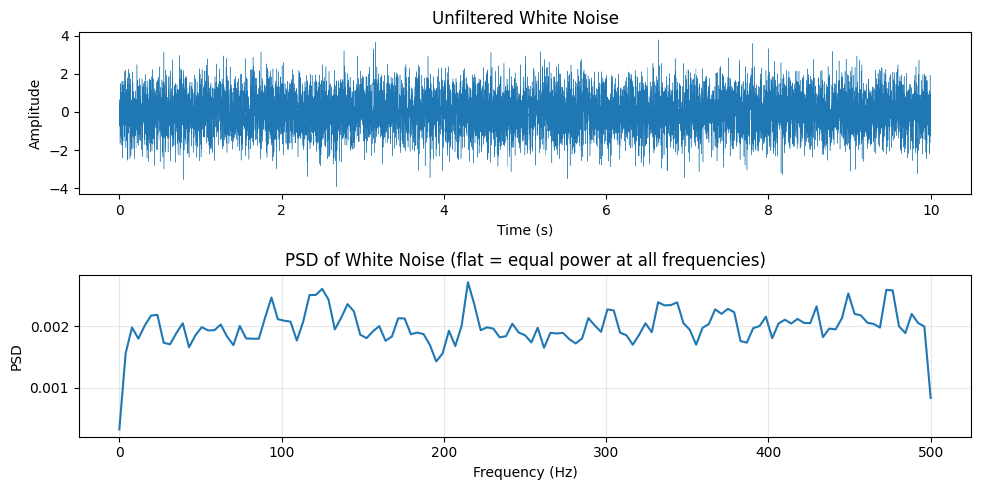

In [20]:
# ---- Generate white noise (flat spectrum) ----

t_noise = np.arange(0, 10, 1/1000)        # 10 seconds at 1000 Hz
y_noise = np.random.randn(len(t_noise))   # White noise

# Show the unfiltered noise and its flat PSD
freqs_n, psd_n = sp.signal.welch(y_noise, fs=1000)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(t_noise, y_noise, linewidth=0.3)
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Unfiltered White Noise')

ax[1].plot(freqs_n, psd_n)
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('PSD')
ax[1].set_title('PSD of White Noise (flat = equal power at all frequencies)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ---- Helper function to plot a filter result ----

def plot_filter_result(t, y_orig, y_filt, fs, title):
    """Plot filtered signal and its PSD."""
    freqs, psd = sp.signal.welch(y_filt, fs=fs)
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].plot(t, y_filt, linewidth=0.3)
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Amplitude')
    ax[0].set_title(title)
    ax[1].plot(freqs, psd)
    ax[1].set_xlabel('Frequency (Hz)')
    ax[1].set_ylabel('PSD')
    ax[1].set_title(f'PSD after filtering')
    ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

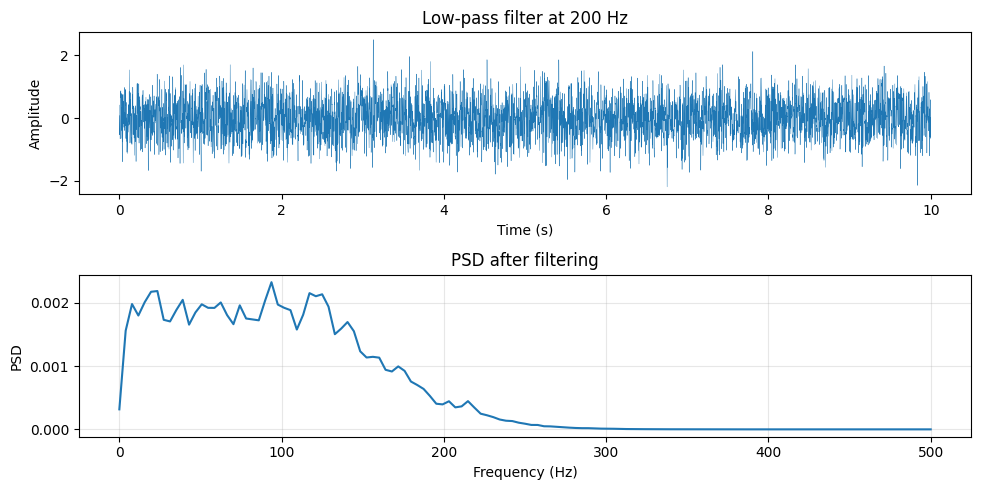

In [22]:
# ---- Low-pass at 200 Hz ----
# Keeps everything BELOW 200 Hz, removes everything above.

yf_low = plg_lowpass(y_noise, 1000, 200)
plot_filter_result(t_noise, y_noise, yf_low, 1000, 'Low-pass filter at 200 Hz')

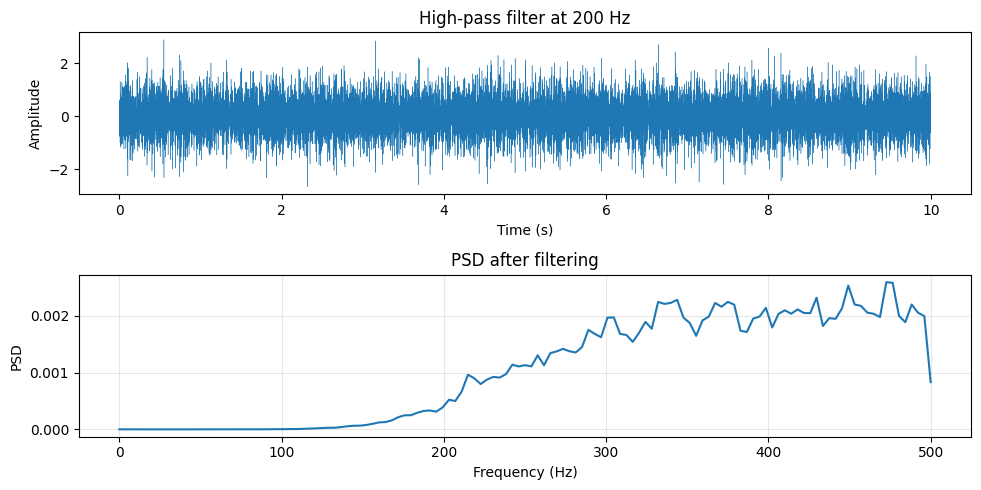

In [23]:
# ---- High-pass at 200 Hz ----
# Keeps everything ABOVE 200 Hz, removes everything below.

yf_high = plg_highpass(y_noise, 1000, 200)
plot_filter_result(t_noise, y_noise, yf_high, 1000, 'High-pass filter at 200 Hz')

In [ ]:
# ---- Band-pass at 200–300 Hz ----
# Keeps ONLY frequencies between 200 and 300 Hz.

yf_band = plg_bandpass(y_noise, 1000, [200, 300])
plot_filter_result(t_noise, y_noise, yf_band, 1000, 'Band-pass filter at 200–300 Hz')

In [ ]:
# ---- Band-stop (notch) at 200–300 Hz ----
# Removes frequencies between 200 and 300 Hz, keeps everything else.

yf_stop = plg_bandstop(y_noise, 1000, [200, 300])
plot_filter_result(t_noise, y_noise, yf_stop, 1000, 'Band-stop (notch) filter at 200–300 Hz')

---
## 11. Phase Distortion: `lfilter` vs `filtfilt` <a id='11'></a>

When a filter processes a signal in one direction, it introduces a **phase shift** — the output is delayed relative to the input. This is a problem in motor control research because it distorts the **timing** of events (reaction times, movement onsets, etc.).

The solution is **zero-phase filtering** with `filtfilt`, which applies the filter forward and then backward, canceling out the phase shift.

| Function | Phase shift? | Latency? | Use when |
|---|---|---|---|
| `signal.lfilter(b, a, y)` | **Yes** — output is shifted | Yes | Real-time / causal processing |
| `signal.filtfilt(b, a, y)` | **No** — zero-phase | None | Offline analysis (most research) |

In [ ]:
# ---- Create a noisy sine wave to demonstrate phase shift ----

np.random.seed(42)
fs = 30                                    # Low sampling rate to make the shift visible
ts = np.arange(0, 5, 1.0 / fs)            # 5 seconds
y_signal = np.sin(2*np.pi * 1.0 * ts)     # Clean 1 Hz sine
y_noise_demo = 0.5 * np.random.randn(len(ts))  # Noise
y_raw = y_signal + y_noise_demo            # Noisy signal

# Design a 4th-order low-pass Butterworth at 2.5 Hz
b, a = scipy.signal.iirfilter(4, Wn=2.5, fs=fs, btype='low', ftype='butter')

In [ ]:
# ---- Compare lfilter (has phase shift) vs filtfilt (zero-phase) ----

y_lfilter = scipy.signal.lfilter(b, a, y_raw)     # Forward only → phase shift!
y_filtfilt = scipy.signal.filtfilt(b, a, y_raw)    # Forward + backward → zero phase

plt.figure(figsize=(10, 4))
plt.plot(ts, y_raw, alpha=0.5, label='Raw signal')
plt.plot(ts, y_lfilter, alpha=0.8, linewidth=2, label='lfilter (has phase shift!)')
plt.plot(ts, y_filtfilt, alpha=0.8, linewidth=2, label='filtfilt (zero-phase ✓)')
plt.plot(ts, y_signal, 'k--', alpha=0.4, label='True signal (no noise)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('lfilter vs filtfilt — Notice the Phase Shift!')
plt.legend(loc='lower center', bbox_to_anchor=[0.5, 1], ncol=4, fontsize='smaller')
plt.tight_layout()
plt.show()

print("Notice: lfilter output is SHIFTED to the right (delayed).")
print("filtfilt output aligns perfectly with the true signal — no phase distortion.")
print("\nRule: ALWAYS use filtfilt for offline analysis in research.")

**Critical takeaway for research:** `filtfilt` is what you should use for almost all offline analysis. The filter functions defined in Section 9 already use `filtfilt` — that's why we built them that way.

---
# Part III — Practice

## 12. Exercises <a id='12'></a>

---

### Exercise 1: Build and Analyze a Signal

1. Create a signal with $f_s = 500$ Hz and $N = 2000$ samples.
2. The signal should contain a 60 Hz sinusoid (amplitude 0.4) and a 140 Hz sinusoid (amplitude 0.8).
3. Plot the full signal in one panel and the first 200 samples in another.
4. Compute the FFT and verify that you can see peaks at 60 and 140 Hz.

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 2: Remove Power-Line Noise

Power-line interference at 60 Hz is the most common noise source in electrophysiology.

1. Create a 2-second signal at 1000 Hz containing a 10 Hz sine (amplitude 1.0) + 60 Hz interference (amplitude 0.5) + random noise.
2. Plot the PSD and confirm both peaks.
3. Use the `plg_bandstop` function to notch out 58–62 Hz.
4. Plot the PSD of the filtered signal. Is the 60 Hz peak gone?

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 3: EMG Envelope Extraction

A common EMG processing pipeline is:
1. High-pass at 20 Hz (remove movement artifact)
2. Full-wave rectify (`np.abs()`)
3. Low-pass at 6 Hz (smooth to get the activation envelope)

Simulate an EMG signal: multiply a slow Gaussian burst (envelope) by broadband noise (motor units). Then apply the pipeline and compare the recovered envelope to the original.

In [ ]:
# ---- YOUR CODE HERE ----

# Hint: start with something like this:
# fs = 1000
# t = np.arange(0, 2, 1/fs)
# envelope = np.exp(-0.5 * ((t - 1.0) / 0.2)**2)   # Gaussian burst at t=1s
# emg = envelope * np.random.randn(len(t))           # EMG = envelope × noise

# Step 1: high-pass at 20 Hz
# Step 2: rectify with np.abs()
# Step 3: low-pass at 6 Hz
# Compare to original envelope

### Exercise 4: Filter Order Comparison (Challenge)

1. Create white noise at 1000 Hz.
2. Apply a low-pass filter at 100 Hz with orders 1, 2, 4, and 8.
3. Plot the PSD of each on the same axes.
4. How does the rolloff steepness change with order? What is the tradeoff with higher orders?

In [ ]:
# ---- YOUR CODE HERE ----


---
## 13. Summary & Further Reading <a id='13'></a>

### What You Learned

| Concept | Function | When to use |
|---|---|---|
| **FFT** | `sp.fft.fft()` or `sp.fft.rfft()` | Decompose signal into frequency components |
| **Frequency axis** | `scipy.fft.rfftfreq(N, 1/fs)` | Get the Hz value for each FFT bin |
| **Inverse FFT** | `sp.fft.ifft()` | Convert frequency domain back to time domain |
| **PSD (Welch)** | `scipy.signal.welch(y, fs)` | Smooth power spectrum (standard for papers) |
| **Spectrogram** | `scipy.signal.spectrogram(y, fs)` | Frequency content over time |
| **Butterworth design** | `scipy.signal.butter(order, Wn, btype)` | Design low/high/band-pass filters |
| **Zero-phase filter** | `scipy.signal.filtfilt(b, a, y)` | Apply filter without phase distortion |
| **Causal filter** | `scipy.signal.lfilter(b, a, y)` | Real-time filtering (has phase shift) |

### The Signal Processing Recipe

1. **Inspect** the raw signal (plot time series + PSD)
2. **Identify** noise sources (broadband? power-line? drift?)
3. **Choose** the appropriate filter type and cutoff
4. **Apply** with `filtfilt` (zero-phase, offline analysis)
5. **Verify** by plotting the filtered PSD

### Common Filter Settings in Movement Neuroscience

| Signal type | Typical filter | Cutoff |
|---|---|---|
| Kinematics (position) | Low-pass Butterworth, order 2 | 6–10 Hz |
| Force plate | Low-pass Butterworth, order 4 | 10–20 Hz |
| EMG | Band-pass Butterworth, order 2 | 20–450 Hz |
| EMG envelope | Low-pass after rectification | 6 Hz |
| EEG | Band-pass | 0.5–100 Hz |
| Power-line removal | Notch (band-stop) | 58–62 Hz (or 48–52 Hz) |

### Further Reading

- [SciPy Signal Processing Tutorial](https://docs.scipy.org/doc/scipy/tutorial/signal.html) — official documentation
- [SciPy Butterworth Filter Design](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)
- [Think DSP](https://greenteapress.com/thinkdsp/html/index.html) — free online textbook on digital signal processing in Python
- [Winter — *Biomechanics and Motor Control*](https://www.wiley.com/en-us/Biomechanics+and+Motor+Control+of+Human+Movement%2C+4th+Edition-p-9780470398180) — Chapter 2 covers signal processing for biomechanics
- [De Luca et al. (2010)](https://doi.org/10.1016/j.jbiomech.2009.09.048) — EMG filtering recommendations

---

*Happy filtering, and may your signals always be cleaner than your raw data!*